In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv

import sumo_rl_ego as sre
from human_feedback_rl.common.trajectory_generators import TrajectoryGeneratorFromAgent

from loadings import load_reward_ensemble
from notebooks.plot_functions import plot_scatter_from_segments
from plot_functions import plot_scatter, plot_reward_curves

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

In [36]:
CHECKPOINT_DIR = Path("/Users/andreazhang/Documents/fis/sumo-human-feedback-rl/outputs/seg1_fragrandom_comps2000_seed10/checkpoint_0100")

import sumo_gym_ego.core.simulation as _sim_mod
import traci as _traci_mod
_sim_mod.load_traci = lambda use_gui: _traci_mod

try:
    env.close()
except Exception:
    pass

env = sre.make_vec_env(
    "HighwayEgo-v0",
    n_envs=1,
    base_seed=0,
    ego="continuous",
    reward="fast"
)

reward_model = load_reward_ensemble(
    CHECKPOINT_DIR / "reward_model.pt",
    env.observation_space,
    env.action_space,
)


Environment closed.


In [37]:
import pickle

SAVE_PATH = "debug_dataset_seg1.pkl"

with open(SAVE_PATH, "rb") as f:
     data = pickle.load(f)

In [38]:

STATUS_ARRIVED  = 0
STATUS_COLLIDED = 1
STATUS_OFFROAD  = 2
STATUS_TIMEOUT  = 3
STATUS_RUNNING  = 4

data_conc = (
    data[STATUS_ARRIVED] +
    data[STATUS_COLLIDED] +
    data[STATUS_OFFROAD] +
    data[STATUS_TIMEOUT]
    + data[STATUS_RUNNING]
)

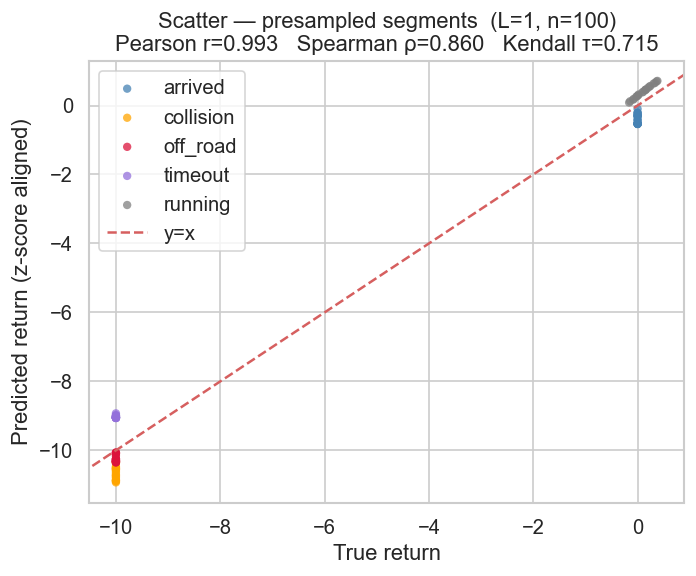

Pearson=0.993  Spearman=0.860  Kendall=0.715  n=100


In [39]:
plot_scatter_from_segments(data_conc, reward_model, normalize=True, robust=False)